### Load relevant libraries

In [54]:
import os
import pandas as pd
pd.set_option('display.max_columns', None)

import numpy as np

import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.datasets import make_classification
from sklearn.feature_selection import RFECV

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, log_loss, accuracy_score
from sklearn.metrics import brier_score_loss
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.calibration import calibration_curve

### Read in the data

In [55]:
# Set working directory (necessary until 2019 data comes out)
path = 'C:/Users/caanm/OneDrive/Documents/Project Portfolio/March Madness 2026/2026 Data'
os.chdir(path)

In [56]:
df_all = pd.read_csv('dyad_matchups.csv', sep=',', index_col=None)
games_to_pred = pd.read_csv('games_to_predict.csv', sep=',', index_col=None)
team_a_stats = pd.read_csv('team_a_stats.csv', sep=',', index_col=None)
team_b_stats = pd.read_csv('team_b_stats.csv', sep=',', index_col=None)

### Prep the Data

In [57]:
# create a list including the desired explanatory variables
column_names = df_all.columns.values.tolist()

with pd.option_context('display.max_columns', None):
    print(df_all[column_names].head()), df_all[column_names].shape

   Season  team_a  team_b  team_a_win  top_a  mid_a  bot_a  intourney_a  \
0    2022    1231    1461           1      0      1      0          1.0   
1    2022    1394    1411           0      1      0      0          1.0   
2    2022    1323    1353           1      0      0      1          1.0   
3    2022    1136    1460           0      0      1      0          1.0   
4    2022    1116    1436           1      1      0      0          1.0   

   top_b  mid_b  bot_b  intourney_b  efg_diff   sa_diff   pt_diff  rank_diff  \
0      1      0      0          1.0  0.123279 -0.466673 -0.083709          3   
1      1      0      0          1.0 -0.223596  0.399081 -0.134725          0   
2      0      1      0          1.0  0.953422  0.732658  0.378520          4   
3      0      0      1          1.0 -1.008504  1.952189 -0.062424         -4   
4      1      0      0          1.0 -1.947198  0.317117 -0.739062          1   

   winsbefore_diff  winsafter_diff  clutch_diff  close_diff  grit_di

In [58]:
# Drop unnecessary variables: 
column_names = np.delete(column_names, [0, 1, 2, 3, 6, 7, 10, 11])

with pd.option_context('display.max_columns', None):
    print(df_all[column_names].head()), df_all[column_names].shape

   top_a  mid_a  top_b  mid_b  efg_diff   sa_diff   pt_diff  rank_diff  \
0      0      1      1      0  0.123279 -0.466673 -0.083709          3   
1      1      0      1      0 -0.223596  0.399081 -0.134725          0   
2      0      0      0      1  0.953422  0.732658  0.378520          4   
3      0      1      0      0 -1.008504  1.952189 -0.062424         -4   
4      1      0      1      0 -1.947198  0.317117 -0.739062          1   

   winsbefore_diff  winsafter_diff  clutch_diff  close_diff  grit_diff  \
0        -0.672530       -0.449176    -1.839140    0.211692  -2.412397   
1         0.472988       -0.661514     0.916100   -1.774185  -2.412397   
2        -0.174259        0.757985     0.864850   -0.686781   1.206199   
3         0.015918        0.898353     0.971621   -1.419348  -1.182384   
4         0.248319       -1.065773     0.000000    0.584674   2.412397   

   has_ot_diff  off_diff  def_diff  ast_diff   to_diff  stl_diff  blk_diff  \
0    -1.356835 -0.058910  0.0411

###### Dropped:
> ###### Season, team_a, team_b as these aren't predictors
> ###### team_a_win as this is our dependent variable
> ###### bot_a, bot_b to avoid multicollinearity
> ###### intourney_a, intourney_b since this is accounted for in winpercintourney

In [59]:
# Check for NaNs
print(df_all[column_names].isnull().sum())

# Set all NaN to 0
df_vars = df_all[column_names].fillna(0)

# Check for NaN's
# print(df_vars.isnull().sum())

top_a                    0
mid_a                    0
top_b                    0
mid_b                    0
efg_diff                 0
sa_diff                  0
pt_diff                  0
rank_diff                0
winsbefore_diff          0
winsafter_diff           0
clutch_diff              0
close_diff               0
grit_diff                0
has_ot_diff              0
off_diff                 0
def_diff                 0
ast_diff                 0
to_diff                  0
stl_diff                 0
blk_diff                 0
or_diff                  0
dr_diff                  0
3m_diff                  0
3a_diff                  0
seed_diff                0
conf_diff                0
winpercintourney_diff    0
dtype: int64


In [60]:
display(df_vars.head())

,top_a,mid_a,top_b,mid_b,efg_diff,sa_diff,pt_diff,rank_diff,winsbefore_diff,winsafter_diff,clutch_diff,close_diff,grit_diff,has_ot_diff,off_diff,def_diff,ast_diff,to_diff,stl_diff,blk_diff,or_diff,dr_diff,3m_diff,3a_diff,seed_diff,conf_diff,winpercintourney_diff
0,0,1,1,0,0.123279,-0.466673,-0.083709,3,-0.672530,-0.449176,-1.839140,0.211692,-2.412397,-1.356835,-0.058910,0.041184,2.038143,0.307274,1.256320,2.806270,0.301169,-0.262428,-0.871038,-1.216128,0.0,6.0,0.500000
1,1,0,1,0,-0.223596,0.399081,-0.134725,0,0.472988,-0.661514,0.916100,-1.774185,-2.412397,-0.023727,0.684506,0.910136,1.404097,-0.153717,1.678516,-3.281965,0.311260,-1.045113,0.082365,0.127126,0.0,2.0,-0.500000
2,0,0,0,1,0.953422,0.732658,0.378520,4,-0.174259,0.757985,0.864850,-0.686781,1.206199,0.000000,0.608846,0.184594,-0.404406,-0.540938,-1.395293,-2.023982,-1.612410,1.011400,1.853222,1.517316,0.0,-3.0,0.666667
3,0,1,0,0,-1.008504,1.952189,-0.062424,-4,0.015918,0.898353,0.971621,-1.419348,-1.182384,1.426481,0.193547,0.287855,-0.221859,0.411605,0.371699,1.275345,0.822259,1.691796,1.233609,2.027859,0.0,-3.0,-0.500000
4,1,0,1,0,-1.947198,0.317117,-0.739062,1,0.248319,-1.065773,0.000000,0.584674,2.412397,1.269149,0.330585,1.284756,-0.487217,1.177091,1.619460,1.713927,2.150837,-0.307921,-1.512763,-0.816450,9.0,24.0,0.750000


### XGBoost with RFECV

In [61]:
### Define y and X
y = df_all['team_a_win'].astype(int)
X_orig = df_vars.copy()

# Build XGBoost model
xgb_model = XGBClassifier(
    objective='binary:logistic', 
    random_state=42, 
    use_label_encoder=False, 
    eval_metric='logloss'
)

# Run RFECV
rfecv_orig = RFECV(
    estimator=xgb_model, 
    step=1,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), 
    scoring='accuracy',
    verbose=0,
    n_jobs=-1
)

rfecv_orig = rfecv_orig.fit(X_orig, y)

C:\Users\caanm\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:37:53] WARNING: C:\Users\task_177203131132615\croot\xgboost-split_1772031744563\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\caanm\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:37:54] WARNING: C:\Users\task_177203131132615\croot\xgboost-split_1772031744563\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\caanm\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:37:54] WARNING: C:\Users\task_177203131132615\croot\xgboost-split_1772031744563\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\caanm\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:37:55] WARNING: C:\Users\task_177203131132615\croot\xgboo

In [62]:
# Output selected features
selected_features_orig = X_orig.columns[rfecv_orig.support_]

print('Selected Features:')
print(selected_features_orig)

print('\nFeature rankings:')
print(rfecv_orig.ranking_)

Selected Features:
Index(['pt_diff', 'winsbefore_diff', 'winsafter_diff', 'clutch_diff',
       'seed_diff', 'conf_diff', 'winpercintourney_diff'],
      dtype='object')

Feature rankings:
[14 20 17 19 11 12  1 13  1  1  1 10 18  5 21  3  8 16 15  4  2  6  7  9
  1  1  1]


##### Only 7 features of the original 29 were selected by RFECV
##### As we saw in the RFECV Logistic model, several features were highly correlated; it seems that many of these were removed
> ##### pt_diff kept, but off_diff, def_diff, efg_diff, and so on were removed
#####
##### Let's look at feature importance

In [63]:
### Refit final model on selected features
final_xgb_model = XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

final_xgb_model.fit(X_orig[selected_features_orig], y)

C:\Users\caanm\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:38:02] WARNING: C:\Users\task_177203131132615\croot\xgboost-split_1772031744563\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [64]:
# Feature importance
importances = final_xgb_model.feature_importances_

importance_table = pd.DataFrame({
    'Feature': selected_features_orig,
    'Importance': importances
}).sort_values('Importance', ascending=False)

display(importance_table)

,Feature,Importance
0,pt_diff,0.549487
5,conf_diff,0.154950
6,winpercintourney_diff,0.079953
1,winsbefore_diff,0.066939
2,winsafter_diff,0.056791
3,clutch_diff,0.050388
4,seed_diff,0.041491


##### point differential is the most important feature, almost 4x the next
##### conference strength also plays a role
> ##### better teams in strong divisions have higher performance when playing against teams from weaker divisions
##### postseason experience (winperintourney) contributes
##### early- and late-season performance are strongly predictive
##### 'clutch' teams help differentiate when teams are similar
> ##### clutch_diff - a created metric that measures success in close games - also makes the cut
##### Seed_diff plays a small role here, but was dropped from the Logistic RFECV

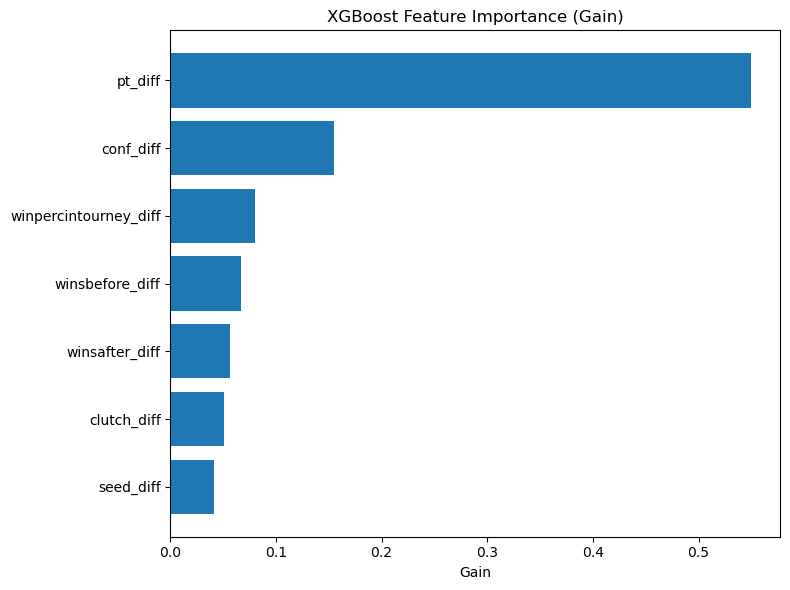

In [65]:
features = np.array(selected_features_orig)
importances = np.array(final_xgb_model.feature_importances_)

sorted_idx = np.argsort(importances)[::-1]   # reverse sort = descending
features_sorted = features[sorted_idx]
importances_sorted = importances[sorted_idx]

# Plot
plt.figure(figsize=(8,6))
plt.barh(features_sorted, importances_sorted)
plt.xlabel('Gain')
plt.ylabel('')
plt.title('XGBoost Feature Importance (Gain)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

##### Interpreting 'gain' - the average improvement in model performance when a feature is used
> ##### XGBoost builds decision trees by splitting on features to reduce model error
> ##### Each split reduces the log-loss (our evaluation metric), and this reduction is called gain.
> ##### A feature’s gain score reflects the average improvement in model performance from all splits that used that feature.
> ##### Higher gain = the feature produces more effective splits → stronger predictor.
#####
##### pt_diff had by far the highest gain
> ##### produced the largest reductions in log-loss and is the strongest single predictor
##### conf_diff produced meaningful nonlinear splits
> ##### the model used it to set helpful thresholds (e.g., strength gaps between conferences)
##### Other features act as secondary predictors that refine the model
#####
##### As a reminder, all '_diff' metrics are differences in z-scores

##### Some of these variables may be related to each other 
> ##### wins before day 100 are probably correlated with wins after day 100
> ##### those will also likely be determined by conference strength and will help determine seeding
#####
##### Calculate Variance Inflation Factor to look for multicollinearity

### Variance Inflation Factor (VIF)

In [66]:
# Use the RFECV features
X_selected = X_orig[selected_features_orig]

# Add constant
X_vif = sm.add_constant(X_selected)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# Sort by VIF desc
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)
display(vif_data)

,Feature,VIF
0,pt_diff,7.725285
1,winsbefore_diff,5.524732
2,winsafter_diff,2.661090
3,clutch_diff,1.409203
4,conf_diff,1.321783
5,seed_diff,1.277059
6,winpercintourney_diff,1.243701
7,const,1.004887


##### Interpreting VIF
> ##### ~1 means no multicollinearity
> ##### > 5 moderate correlation
> ##### > 10 high multicollinearity (consider removing or combining)

##### We don't see a ton of correlation among selected variables
##### pt_diff is the highest at ~7.7, which is well under the cutoff of 10
##### winsbefore_diff is the only other metric of some concern at 5.5
> ##### teams with higher point differentials are likely to have more wins, rather than mainly close losses with a handful of blowout wins, for example
#####
##### Does not seem that any revisions are necessary based on selected feature importance and correlation

### Evaluating model on Test Data

In [67]:
# Define y and X
y = df_all['team_a_win'].astype(int)
X = df_vars[selected_features_orig]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Fit XGBoost on Train data
xgb_final = XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    eval_metric = 'logloss'
)

xgb_final.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [68]:
# Predict on the test data
y_pred_prob = xgb_final.predict_proba(X_test)[:,1]
y_pred = (y_pred_prob >= 0.5).astype(int)

#### Accuracy, Log Loss, ROC AUC

In [69]:
# Evaluate model performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Log Loss:", log_loss(y_test, y_pred_prob))
print("ROC AUC:", accuracy_score(y_test, y_pred))

Accuracy: 0.7609600969183009
Log Loss: 0.48459368970189115
ROC AUC: 0.7609600969183009


##### ~76% games are correctly predicted with a 0.5 cutoff
##### 0.48 Log Loss suggests good calibration (< 0.5); method penalizes wrong predictions heavily
##### 0.76 ROC AUC is slightly closer to 1.0 (perfect separation) than 0.5 (random guessing)

In [70]:
# Brier score for Kaggle
print("Brier Score:", brier_score_loss(y_test, y_pred_prob))

Brier Score: 0.1600230903329597


In [71]:
# Confusion matrix and Classification Report

confusion_matrix = confusion_matrix(y_test, y_pred)
print(confusion_matrix)
# 4988 True Negatives; 1604 False Negatives
# 5062 True Positives; 1553 False Positives


print(classification_report(y_test, y_pred))
# 76% Precision: True Positives / TP + FP
# 76-77% Recall: True Positives / TP + FN
# 76-76% F1-Score: 2 * (Precision * Recall) / (Precision + Recall)

[[4988 1604]
 [1553 5062]]
              precision    recall  f1-score   support

           0       0.76      0.76      0.76      6592
           1       0.76      0.77      0.76      6615

    accuracy                           0.76     13207
   macro avg       0.76      0.76      0.76     13207
weighted avg       0.76      0.76      0.76     13207



##### False negatives are balanced with false positives, meaning model isn't biased toward over-predicting wins or losses; no systematic over/under-confidence
> ##### 1604 False Negatives / 1553 False Positives

##### Balanced across False/True classes, no major bias toward predicting favorites incorrectly
> ##### 0.76-0.77 score across metrics for both False and True

##### F1 around 0.76 aligns with the previously determined accuracy score

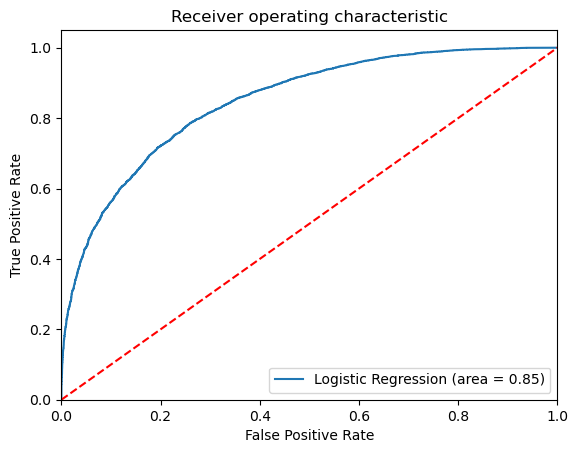

In [72]:
### PLotting the ROC AUC

# ROC AUC
logit_roc_auc = roc_auc_score(y_test, y_pred_prob)

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Plot
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()

#### Calibration Plot

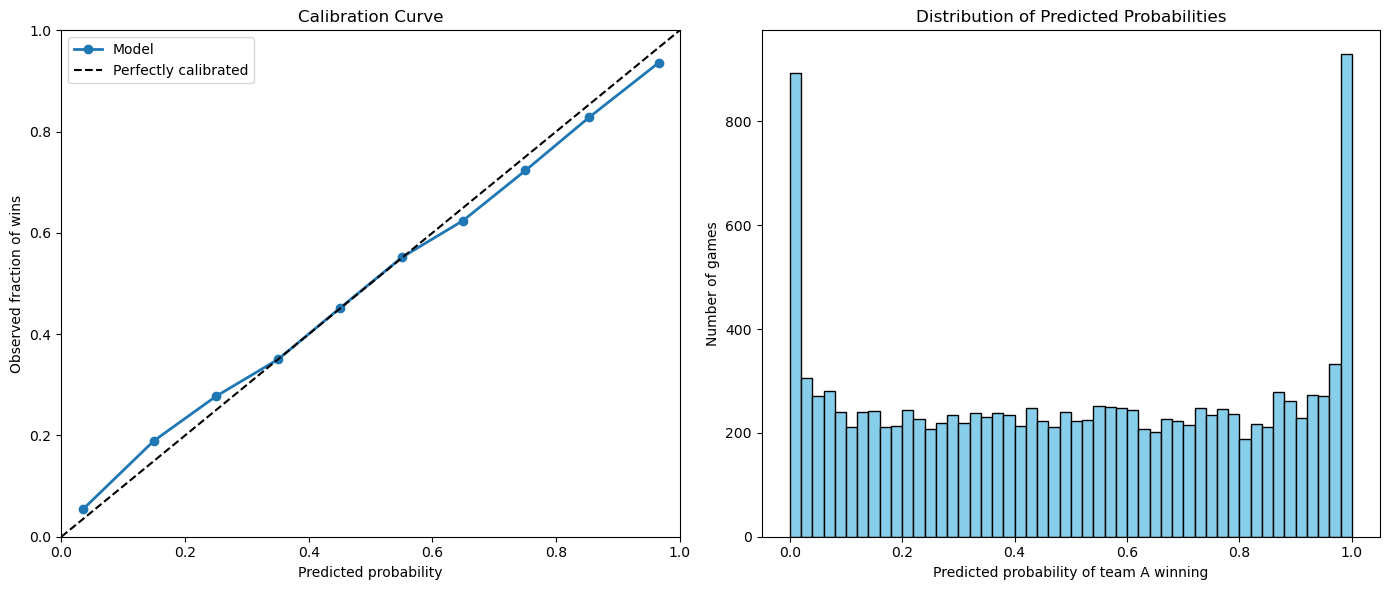

In [73]:
# Calibration curve
prob_true, prob_pred = calibration_curve(y_test, y_pred_prob, n_bins=10)

# Create figure with 2 subplots
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Calibration Curve
ax[0].plot(prob_pred, prob_true, marker='o', linewidth=2, label='Model')
ax[0].plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
ax[0].set_xlabel('Predicted probability')
ax[0].set_ylabel('Observed fraction of wins')
ax[0].set_title('Calibration Curve')
ax[0].legend()
ax[0].set_xlim([0, 1])
ax[0].set_ylim([0, 1])

# Distribution of predicted probabilities
ax[1].hist(y_pred_prob, bins=50, color='skyblue', edgecolor='k')
ax[1].set_xlabel('Predicted probability of team A winning')
ax[1].set_ylabel('Number of games')
ax[1].set_title('Distribution of Predicted Probabilities')

plt.tight_layout()
plt.show()

##### Interpreting the Calibration Curve:
> ##### Points near diagonal means probabilities match actual outcomes
> ##### Points below: model overconfident
> ##### Points above: model is underconfident

##### Interpreting the Probability Distribution
> ##### Spread between 0.1 to 0.9 means model is making meaningful distinctions between favorites and underdogs
> ##### Clustering around 0.5 means model is indecisive

#####

### Print the results

In [74]:
SampleSubmission = pd.read_csv("SampleSubmissionStage2.csv", sep=',', index_col=None)
team_a_2026 = pd.read_csv("team_a_2026.csv", sep=',', index_col=None)
team_b_2026 = pd.read_csv("team_b_2026.csv", sep=',', index_col=None)

##### Remake the dataset for 2026 data

In [75]:
submission = pd.concat([SampleSubmission['ID'], SampleSubmission['ID'].str.split('_', expand=True).rename(
    columns={0:'season', 1:'team_a', 2:'team_b'})], axis=1)
submission.head()

,ID,season,team_a,team_b
0,2026_1101_1102,2026,1101,1102
1,2026_1101_1103,2026,1101,1103
2,2026_1101_1104,2026,1101,1104
3,2026_1101_1105,2026,1101,1105
4,2026_1101_1106,2026,1101,1106


In [76]:
submission[['team_a', 'team_b', 'season']] = submission[['team_a','team_b','season']].astype(int)

In [77]:
pred1 = pd.merge(submission, team_a_2026, how='left', left_on=['season','team_a'], right_on=['Season','team_a']).drop(['Season'], axis=1)
pred2 = pd.merge(pred1, team_b_2026, how='left', left_on=['team_b','season'], right_on=['team_b','Season']).drop(['Season'], axis=1)

In [78]:
pred2.head()

,ID,season,team_a,team_b,conf_a,z.efg_a,z.sa_a,z.pt_a,rank_a,top_a,mid_a,bot_a,z.winsbefore_a,z.winsafter_a,z.clutch_a,z.close_a,z.grit_a,z.has_ot_a,z.off_a,z.def_a,z.ast_a,z.to_a,z.stl_a,z.blk_a,z.or_a,z.dr_a,z.3m_a,z.3a_a,seed_strength_a,M_W_a,conf_strength_a,winpercintourney_a,conf_b,z.efg_b,z.sa_b,z.pt_b,rank_b,top_b,mid_b,bot_b,z.winsbefore_b,z.winsafter_b,z.clutch_b,z.close_b,z.grit_b,z.has_ot_b,z.off_b,z.def_b,z.ast_b,z.to_b,z.stl_b,z.blk_b,z.or_b,z.dr_b,z.3m_b,z.3a_b,seed_strength_b,M_W_b,conf_strength_b,winpercintourney_b
0,2026_1101_1102,2026,1101,1102,wac,-0.162759,-1.197764,-0.653195,10,0,0,1,-0.693469,-0.338242,0.022142,0.244385,-1.275128,-0.402667,-0.240937,0.526532,-0.337955,0.118533,1.30033,-0.678488,-0.469026,-2.115358,-0.808466,-0.859285,17.0,M,21.0,0.0,mwc,-0.175115,-1.203686,-2.076803,20,0,0,1,-1.763332,-1.976930,-1.203073,-1.285651,0.00000,-1.178771,-1.018115,1.379356,-0.504111,0.085482,-0.970406,-0.878070,-1.941526,-1.012617,-0.245519,-0.007985,17.0,M,26.0,0.000000
1,2026_1101_1103,2026,1101,1103,wac,-0.162759,-1.197764,-0.653195,10,0,0,1,-0.693469,-0.338242,0.022142,0.244385,-1.275128,-0.402667,-0.240937,0.526532,-0.337955,0.118533,1.30033,-0.678488,-0.469026,-2.115358,-0.808466,-0.859285,17.0,M,21.0,0.0,mac,2.088606,1.858487,1.446969,4,0,1,0,1.316575,2.119790,0.512228,-0.948143,0.00000,-1.178771,2.058478,0.616427,2.015763,-0.916825,-0.042117,-0.357421,0.220382,1.026064,2.289566,1.692553,5.0,M,16.0,0.000000
2,2026_1101_1104,2026,1101,1104,wac,-0.162759,-1.197764,-0.653195,10,0,0,1,-0.693469,-0.338242,0.022142,0.244385,-1.275128,-0.402667,-0.240937,0.526532,-0.337955,0.118533,1.30033,-0.678488,-0.469026,-2.115358,-0.808466,-0.859285,17.0,M,21.0,0.0,sec,1.132784,3.593371,0.973787,11,0,0,1,1.010385,1.095610,1.247357,0.064381,1.25203,-0.451174,2.646483,1.889455,1.244654,-1.294037,-0.506262,1.920422,0.580700,2.029960,3.329134,3.447199,13.0,M,31.0,0.554167
3,2026_1101_1105,2026,1101,1105,wac,-0.162759,-1.197764,-0.653195,10,0,0,1,-0.693469,-0.338242,0.022142,0.244385,-1.275128,-0.402667,-0.240937,0.526532,-0.337955,0.118533,1.30033,-0.678488,-0.469026,-2.115358,-0.808466,-0.859285,17.0,M,21.0,0.0,swac,0.404848,-1.220059,-0.259354,3,1,0,0,-0.093441,0.299025,0.022142,-0.475631,1.25203,-0.402667,0.175851,0.526532,-0.910779,-0.904610,-0.641934,-0.504938,-0.853365,-0.154929,-0.302665,-0.752100,17.0,M,4.0,0.000000
4,2026_1101_1106,2026,1101,1106,wac,-0.162759,-1.197764,-0.653195,10,0,0,1,-0.693469,-0.338242,0.022142,0.244385,-1.275128,-0.402667,-0.240937,0.526532,-0.337955,0.118533,1.30033,-0.678488,-0.469026,-2.115358,-0.808466,-0.859285,17.0,M,21.0,0.0,swac,-0.275941,0.606209,-0.668243,16,0,0,1,-1.117280,-0.440660,-0.794668,-0.545311,0.00000,-1.178771,0.193995,1.053695,-0.686672,-0.210030,0.312613,0.578909,0.714367,-0.350494,0.235141,0.433855,17.0,M,4.0,0.125000


In [79]:
### Calculate differences
pred2['efg_diff'] = pred2['z.efg_a'] - pred2['z.efg_b']
pred2['sa_diff'] = pred2['z.sa_a'] - pred2['z.sa_b']
pred2['pt_diff'] = pred2['z.pt_a'] - pred2['z.pt_b']
pred2['rank_diff'] = pred2['rank_a'] - pred2['rank_b']
pred2['winsbefore_diff'] = pred2['z.winsbefore_a'] - pred2['z.winsbefore_b']
pred2['winsafter_diff'] = pred2['z.winsafter_a'] - pred2['z.winsafter_b']
pred2['clutch_diff'] = pred2['z.clutch_a'] - pred2['z.clutch_b']
pred2['close_diff'] = pred2['z.close_a'] - pred2['z.close_b']
pred2['grit_diff'] = pred2['z.grit_a'] - pred2['z.grit_b']
pred2['has_ot_diff'] = pred2['z.has_ot_a'] - pred2['z.has_ot_b']
pred2['off_diff'] = pred2['z.off_a'] - pred2['z.off_b']
pred2['def_diff'] = pred2['z.def_a'] - pred2['z.def_b']
pred2['ast_diff'] = pred2['z.ast_a'] - pred2['z.ast_b']
pred2['to_diff'] = pred2['z.to_a'] - pred2['z.to_b']
pred2['stl_diff'] = pred2['z.stl_a'] - pred2['z.stl_b']
pred2['blk_diff'] = pred2['z.blk_a'] - pred2['z.blk_b']
pred2['or_diff'] = pred2['z.or_a'] - pred2['z.or_b']
pred2['dr_diff'] = pred2['z.dr_a'] - pred2['z.dr_b']
pred2['3m_diff'] = pred2['z.3m_a'] - pred2['z.3m_b']
pred2['3a_diff'] = pred2['z.3a_a'] - pred2['z.3a_b']
pred2['winpercintourney_diff'] = pred2['winpercintourney_a'] - pred2['winpercintourney_b']
pred2['seed_diff'] = pred2['seed_strength_a'] - pred2['seed_strength_b']
pred2['conf_diff'] = pred2['conf_strength_a'] - pred2['conf_strength_b']

In [80]:
pred2.head()

,ID,season,team_a,team_b,conf_a,z.efg_a,z.sa_a,z.pt_a,rank_a,top_a,mid_a,bot_a,z.winsbefore_a,z.winsafter_a,z.clutch_a,z.close_a,z.grit_a,z.has_ot_a,z.off_a,z.def_a,z.ast_a,z.to_a,z.stl_a,z.blk_a,z.or_a,z.dr_a,z.3m_a,z.3a_a,seed_strength_a,M_W_a,conf_strength_a,winpercintourney_a,conf_b,z.efg_b,z.sa_b,z.pt_b,rank_b,top_b,mid_b,bot_b,z.winsbefore_b,z.winsafter_b,z.clutch_b,z.close_b,z.grit_b,z.has_ot_b,z.off_b,z.def_b,z.ast_b,z.to_b,z.stl_b,z.blk_b,z.or_b,z.dr_b,z.3m_b,z.3a_b,seed_strength_b,M_W_b,conf_strength_b,winpercintourney_b,efg_diff,sa_diff,pt_diff,rank_diff,winsbefore_diff,winsafter_diff,clutch_diff,close_diff,grit_diff,has_ot_diff,off_diff,def_diff,ast_diff,to_diff,stl_diff,blk_diff,or_diff,dr_diff,3m_diff,3a_diff,winpercintourney_diff,seed_diff,conf_diff
0,2026_1101_1102,2026,1101,1102,wac,-0.162759,-1.197764,-0.653195,10,0,0,1,-0.693469,-0.338242,0.022142,0.244385,-1.275128,-0.402667,-0.240937,0.526532,-0.337955,0.118533,1.30033,-0.678488,-0.469026,-2.115358,-0.808466,-0.859285,17.0,M,21.0,0.0,mwc,-0.175115,-1.203686,-2.076803,20,0,0,1,-1.763332,-1.976930,-1.203073,-1.285651,0.00000,-1.178771,-1.018115,1.379356,-0.504111,0.085482,-0.970406,-0.878070,-1.941526,-1.012617,-0.245519,-0.007985,17.0,M,26.0,0.000000,0.012355,0.005922,1.423609,-10,1.069862,1.638688,1.225215,1.530036,-1.275128,0.776104,0.777178,-0.852825,0.166156,0.033051,2.270736,0.199582,1.472500,-1.102741,-0.562947,-0.851300,0.000000,0.0,-5.0
1,2026_1101_1103,2026,1101,1103,wac,-0.162759,-1.197764,-0.653195,10,0,0,1,-0.693469,-0.338242,0.022142,0.244385,-1.275128,-0.402667,-0.240937,0.526532,-0.337955,0.118533,1.30033,-0.678488,-0.469026,-2.115358,-0.808466,-0.859285,17.0,M,21.0,0.0,mac,2.088606,1.858487,1.446969,4,0,1,0,1.316575,2.119790,0.512228,-0.948143,0.00000,-1.178771,2.058478,0.616427,2.015763,-0.916825,-0.042117,-0.357421,0.220382,1.026064,2.289566,1.692553,5.0,M,16.0,0.000000,-2.251365,-3.056251,-2.100164,6,-2.010044,-2.458032,-0.490086,1.192528,-1.275128,0.776104,-2.299416,-0.089896,-2.353718,1.035358,1.342448,-0.321067,-0.689408,-3.141422,-3.098032,-2.551838,0.000000,12.0,5.0
2,2026_1101_1104,2026,1101,1104,wac,-0.162759,-1.197764,-0.653195,10,0,0,1,-0.693469,-0.338242,0.022142,0.244385,-1.275128,-0.402667,-0.240937,0.526532,-0.337955,0.118533,1.30033,-0.678488,-0.469026,-2.115358,-0.808466,-0.859285,17.0,M,21.0,0.0,sec,1.132784,3.593371,0.973787,11,0,0,1,1.010385,1.095610,1.247357,0.064381,1.25203,-0.451174,2.646483,1.889455,1.244654,-1.294037,-0.506262,1.920422,0.580700,2.029960,3.329134,3.447199,13.0,M,31.0,0.554167,-1.295543,-4.791134,-1.626981,-1,-1.703855,-1.433852,-1.225215,0.180004,-2.527158,0.048507,-2.887421,-1.362923,-1.582609,1.412570,1.806592,-2.598910,-1.049727,-4.145318,-4.137600,-4.306484,-0.554167,4.0,-10.0
3,2026_1101_1105,2026,1101,1105,wac,-0.162759,-1.197764,-0.653195,10,0,0,1,-0.693469,-0.338242,0.022142,0.244385,-1.275128,-0.402667,-0.240937,0.526532,-0.337955,0.118533,1.30033,-0.678488,-0.469026,-2.115358,-0.808466,-0.859285,17.0,M,21.0,0.0,swac,0.404848,-1.220059,-0.259354,3,1,0,0,-0.093441,0.299025,0.022142,-0.475631,1.25203,-0.402667,0.175851,0.526532,-0.910779,-0.904610,-0.641934,-0.504938,-0.853365,-0.154929,-0.302665,-0.752100,17.0,M,4.0,0.000000,-0.567607,0.022296,-0.393840,7,-0.600029,-0.637268,0.000000,0.720017,-2.527158,0.000000,-0.416788,0.000000,0.572824,1.023143,1.942265,-0.173550,0.384339,-1.960429,-0.505801,-0.107185,0.000000,0.0,17.0
4,2026_1101_1106,2026,1101,1106,wac,-0.162759,-1.197764,-0.653195,10,0,0,1,-0.693469,-0.338242,0.022142,0.244385,-1.275128,-0.402667,-0.240937,0.526532,-0.337955,0.118533,1.30033,-0.678488,-0.469026,-2.115358,-0.808466,-0.859285,17.0,M,21.0,0.0,swac,-0.275941,0.606209,-0.668243,16,0,0,1,-1.117280,-0.440660,-0.794668,-0.545311,0.00000,-1.178771,0.193995,1.053695,-0.686672,-0.210030,0.312613,0.578909,0.714367,-0.350494,0.235141,0.433855,17.0,M,4.0,0.125000,0.113182,-1.803973,0.015048,-6,0.423810,0.102418,0.816810,0.789696,-1.275128,0.776104,-0.434932,-0.527163,0.348717,0.32856

In [81]:
pred3 = pred2[['ID','season','team_a','team_b','top_a','mid_a','bot_a','winpercintourney_a',
                          'top_b','mid_b','bot_b','winpercintourney_b',
                          'efg_diff', 'sa_diff', 'pt_diff', 'rank_diff', 'winsbefore_diff', 'winsafter_diff',
                          'clutch_diff', 'close_diff', 'grit_diff', 'has_ot_diff', 'off_diff', 'def_diff', 'ast_diff',
                          'to_diff', 'stl_diff', 'blk_diff', 'or_diff', 'dr_diff', '3m_diff', '3a_diff',
                          'winpercintourney_diff', 'seed_diff', 'conf_diff']].copy()

display(pred3.head(), pred3.shape)

,ID,season,team_a,team_b,top_a,mid_a,bot_a,winpercintourney_a,top_b,mid_b,bot_b,winpercintourney_b,efg_diff,sa_diff,pt_diff,rank_diff,winsbefore_diff,winsafter_diff,clutch_diff,close_diff,grit_diff,has_ot_diff,off_diff,def_diff,ast_diff,to_diff,stl_diff,blk_diff,or_diff,dr_diff,3m_diff,3a_diff,winpercintourney_diff,seed_diff,conf_diff
0,2026_1101_1102,2026,1101,1102,0,0,1,0.0,0,0,1,0.000000,0.012355,0.005922,1.423609,-10,1.069862,1.638688,1.225215,1.530036,-1.275128,0.776104,0.777178,-0.852825,0.166156,0.033051,2.270736,0.199582,1.472500,-1.102741,-0.562947,-0.851300,0.000000,0.0,-5.0
1,2026_1101_1103,2026,1101,1103,0,0,1,0.0,0,1,0,0.000000,-2.251365,-3.056251,-2.100164,6,-2.010044,-2.458032,-0.490086,1.192528,-1.275128,0.776104,-2.299416,-0.089896,-2.353718,1.035358,1.342448,-0.321067,-0.689408,-3.141422,-3.098032,-2.551838,0.000000,12.0,5.0
2,2026_1101_1104,2026,1101,1104,0,0,1,0.0,0,0,1,0.554167,-1.295543,-4.791134,-1.626981,-1,-1.703855,-1.433852,-1.225215,0.180004,-2.527158,0.048507,-2.887421,-1.362923,-1.582609,1.412570,1.806592,-2.598910,-1.049727,-4.145318,-4.137600,-4.306484,-0.554167,4.0,-10.0
3,2026_1101_1105,2026,1101,1105,0,0,1,0.0,1,0,0,0.000000,-0.567607,0.022296,-0.393840,7,-0.600029,-0.637268,0.000000,0.720017,-2.527158,0.000000,-0.416788,0.000000,0.572824,1.023143,1.942265,-0.173550,0.384339,-1.960429,-0.505801,-0.107185,0.000000,0.0,17.0
4,2026_1101_1106,2026,1101,1106,0,0,1,0.0,0,0,1,0.125000,0.113182,-1.803973,0.015048,-6,0.423810,0.102418,0.816810,0.789696,-1.275128,0.776104,-0.434932,-0.527163,0.348717,0.328563,0.987717,-1.257397,-1.183393,-1.764864,-1.043607,-1.293140,-0.125000,0.0,17.0


(132133, 35)

In [82]:
pred3_vars = pred3[list(X.columns)].copy()
pred3_vars.head()

,pt_diff,winsbefore_diff,winsafter_diff,clutch_diff,seed_diff,conf_diff,winpercintourney_diff
0,1.423609,1.069862,1.638688,1.225215,0.0,-5.0,0.000000
1,-2.100164,-2.010044,-2.458032,-0.490086,12.0,5.0,0.000000
2,-1.626981,-1.703855,-1.433852,-1.225215,4.0,-10.0,-0.554167
3,-0.393840,-0.600029,-0.637268,0.000000,0.0,17.0,0.000000
4,0.015048,0.423810,0.102418,0.816810,0.0,17.0,-0.125000


In [83]:
# Check for NaNs
pred3_vars.isnull().sum()

pt_diff                    0
winsbefore_diff            0
winsafter_diff             0
clutch_diff                0
seed_diff                  0
conf_diff                  0
winpercintourney_diff    726
dtype: int64

In [84]:
# Set all NaN to 0
pred3_vars = pred3_vars.fillna(0)
pred3_vars.isnull().sum()

pt_diff                  0
winsbefore_diff          0
winsafter_diff           0
clutch_diff              0
seed_diff                0
conf_diff                0
winpercintourney_diff    0
dtype: int64

##### Predict 2026 results

In [85]:
# Define X as list of selected variables
X_2026 = pred3_vars

In [86]:
# Predict probabilities
y_pred_prob = xgb_final.predict_proba(X_2026)[:, 1]

In [87]:
pred3['pred'] = y_pred_prob

In [88]:
display(pred3.head(), pred3.shape)

,ID,season,team_a,team_b,top_a,mid_a,bot_a,winpercintourney_a,top_b,mid_b,bot_b,winpercintourney_b,efg_diff,sa_diff,pt_diff,rank_diff,winsbefore_diff,winsafter_diff,clutch_diff,close_diff,grit_diff,has_ot_diff,off_diff,def_diff,ast_diff,to_diff,stl_diff,blk_diff,or_diff,dr_diff,3m_diff,3a_diff,winpercintourney_diff,seed_diff,conf_diff,pred
0,2026_1101_1102,2026,1101,1102,0,0,1,0.0,0,0,1,0.000000,0.012355,0.005922,1.423609,-10,1.069862,1.638688,1.225215,1.530036,-1.275128,0.776104,0.777178,-0.852825,0.166156,0.033051,2.270736,0.199582,1.472500,-1.102741,-0.562947,-0.851300,0.000000,0.0,-5.0,0.794551
1,2026_1101_1103,2026,1101,1103,0,0,1,0.0,0,1,0,0.000000,-2.251365,-3.056251,-2.100164,6,-2.010044,-2.458032,-0.490086,1.192528,-1.275128,0.776104,-2.299416,-0.089896,-2.353718,1.035358,1.342448,-0.321067,-0.689408,-3.141422,-3.098032,-2.551838,0.000000,12.0,5.0,0.437790
2,2026_1101_1104,2026,1101,1104,0,0,1,0.0,0,0,1,0.554167,-1.295543,-4.791134,-1.626981,-1,-1.703855,-1.433852,-1.225215,0.180004,-2.527158,0.048507,-2.887421,-1.362923,-1.582609,1.412570,1.806592,-2.598910,-1.049727,-4.145318,-4.137600,-4.306484,-0.554167,4.0,-10.0,0.007104
3,2026_1101_1105,2026,1101,1105,0,0,1,0.0,1,0,0,0.000000,-0.567607,0.022296,-0.393840,7,-0.600029,-0.637268,0.000000,0.720017,-2.527158,0.000000,-0.416788,0.000000,0.572824,1.023143,1.942265,-0.173550,0.384339,-1.960429,-0.505801,-0.107185,0.000000,0.0,17.0,0.715502
4,2026_1101_1106,2026,1101,1106,0,0,1,0.0,0,0,1,0.125000,0.113182,-1.803973,0.015048,-6,0.423810,0.102418,0.816810,0.789696,-1.275128,0.776104,-0.434932,-0.527163,0.348717,0.328563,0.987717,-1.257397,-1.183393,-1.764864,-1.043607,-1.293140,-0.125000,0.0,17.0,0.882329


(132133, 36)

##### Create Kaggle submission file

In [89]:
pred3[['ID', 'pred']].to_csv('kaggle_submission_XGBoost.csv', index=False)

In [90]:
#pred3.to_csv('2026_full_prediction.csv', index=False)

##### Merge with Team Name data frame to more easily fill out brackets

In [91]:
M_Teams = pd.read_csv("MTeams.csv", sep=',', index_col=None)
W_Teams = pd.read_csv("WTeams.csv", sep=',', index_col=None)
Teams = pd.concat([M_Teams,W_Teams])

Teams.head()

,TeamID,TeamName,FirstD1Season,LastD1Season
0,1101,Abilene Chr,2014.0,2026.0
1,1102,Air Force,1985.0,2026.0
2,1103,Akron,1985.0,2026.0
3,1104,Alabama,1985.0,2026.0
4,1105,Alabama A&M,2000.0,2026.0


In [92]:
result1 = pred3.merge(Teams, how='left', left_on='team_a', right_on='TeamID').rename(
    columns={'TeamName':'team_a_name'}).drop(['TeamID','FirstD1Season','LastD1Season'], axis=1)
result2 = result1.merge(Teams, how='left', left_on='team_b', right_on='TeamID').rename(
    columns={'TeamName':'team_b_name'}).drop(['TeamID','FirstD1Season','LastD1Season'], axis=1)
display(result2.head(), result2.shape)

,ID,season,team_a,team_b,top_a,mid_a,bot_a,winpercintourney_a,top_b,mid_b,bot_b,winpercintourney_b,efg_diff,sa_diff,pt_diff,rank_diff,winsbefore_diff,winsafter_diff,clutch_diff,close_diff,grit_diff,has_ot_diff,off_diff,def_diff,ast_diff,to_diff,stl_diff,blk_diff,or_diff,dr_diff,3m_diff,3a_diff,winpercintourney_diff,seed_diff,conf_diff,pred,team_a_name,team_b_name
0,2026_1101_1102,2026,1101,1102,0,0,1,0.0,0,0,1,0.000000,0.012355,0.005922,1.423609,-10,1.069862,1.638688,1.225215,1.530036,-1.275128,0.776104,0.777178,-0.852825,0.166156,0.033051,2.270736,0.199582,1.472500,-1.102741,-0.562947,-0.851300,0.000000,0.0,-5.0,0.794551,Abilene Chr,Air Force
1,2026_1101_1103,2026,1101,1103,0,0,1,0.0,0,1,0,0.000000,-2.251365,-3.056251,-2.100164,6,-2.010044,-2.458032,-0.490086,1.192528,-1.275128,0.776104,-2.299416,-0.089896,-2.353718,1.035358,1.342448,-0.321067,-0.689408,-3.141422,-3.098032,-2.551838,0.000000,12.0,5.0,0.437790,Abilene Chr,Akron
2,2026_1101_1104,2026,1101,1104,0,0,1,0.0,0,0,1,0.554167,-1.295543,-4.791134,-1.626981,-1,-1.703855,-1.433852,-1.225215,0.180004,-2.527158,0.048507,-2.887421,-1.362923,-1.582609,1.412570,1.806592,-2.598910,-1.049727,-4.145318,-4.137600,-4.306484,-0.554167,4.0,-10.0,0.007104,Abilene Chr,Alabama
3,2026_1101_1105,2026,1101,1105,0,0,1,0.0,1,0,0,0.000000,-0.567607,0.022296,-0.393840,7,-0.600029,-0.637268,0.000000,0.720017,-2.527158,0.000000,-0.416788,0.000000,0.572824,1.023143,1.942265,-0.173550,0.384339,-1.960429,-0.505801,-0.107185,0.000000,0.0,17.0,0.715502,Abilene Chr,Alabama A&M
4,2026_1101_1106,2026,1101,1106,0,0,1,0.0,0,0,1,0.125000,0.113182,-1.803973,0.015048,-6,0.423810,0.102418,0.816810,0.789696,-1.275128,0.776104,-0.434932,-0.527163,0.348717,0.328563,0.987717,-1.257397,-1.183393,-1.764864,-1.043607,-1.293140,-0.125000,0.0,17.0,0.882329,Abilene Chr,Alabama St


(132133, 38)

In [93]:
results_for_bracket = result2[['team_a','team_a_name','team_b','team_b_name','pred']]
results_for_bracket.to_csv('bracket_submission_XGBoost.csv', index=False)

### Comparison with Original Model

##### Model performance is relatively similar
> ##### Confusion matrix and Classification report have similar numbers and balance
> ##### ROC AUC is 0.86 for both models
> ##### Calibration curve and Probability distribution look similar

#### Are predicted outcomes different?

In [94]:
### Pruned model
XGBoost_model = pred3[['ID', 'pred']].copy()
XGBoost_model['win_XGBoost'] = XGBoost_model.apply(lambda XGBoost_model: ('Win' if XGBoost_model['pred'] > 0.5 else 'Loss'), axis=1)
XGBoost_model = XGBoost_model.rename(columns={'pred':'pred_XGBoost'})
display(XGBoost_model.head(), XGBoost_model.shape)

,ID,pred_XGBoost,win_XGBoost
0,2026_1101_1102,0.794551,Win
1,2026_1101_1103,0.437790,Loss
2,2026_1101_1104,0.007104,Loss
3,2026_1101_1105,0.715502,Win
4,2026_1101_1106,0.882329,Win


(132133, 3)

In [95]:
pruned_model = pd.read_csv("kaggle_submission_pruned.csv", sep=',', index_col=None)

In [96]:
pruned_model['win_pruned'] = pruned_model.apply(lambda pruned_model: ('Win' if pruned_model['pred'] > 0.5 else 'Loss'), axis=1)
pruned_model = pruned_model.rename(columns={'pred':'pred_pruned'})
display(pruned_model.head(), pruned_model.shape)

,ID,pred_pruned,win_pruned
0,2026_1101_1102,0.790232,Win
1,2026_1101_1103,0.099033,Loss
2,2026_1101_1104,0.022631,Loss
3,2026_1101_1105,0.788535,Win
4,2026_1101_1106,0.877881,Win


(132133, 3)

In [97]:
model_comp = XGBoost_model.merge(pruned_model,how='inner',on='ID')
display(model_comp.head(),model_comp.shape)

,ID,pred_XGBoost,win_XGBoost,pred_pruned,win_pruned
0,2026_1101_1102,0.794551,Win,0.790232,Win
1,2026_1101_1103,0.437790,Loss,0.099033,Loss
2,2026_1101_1104,0.007104,Loss,0.022631,Loss
3,2026_1101_1105,0.715502,Win,0.788535,Win
4,2026_1101_1106,0.882329,Win,0.877881,Win


(132133, 5)

In [98]:
model_comp['pred_diff'] = model_comp['pred_XGBoost'] - model_comp['pred_pruned']
model_comp['flip'] = (model_comp['pred_XGBoost'] > 0.5) != (model_comp['pred_pruned'] > 0.5)
display(model_comp.head(),model_comp.shape)

,ID,pred_XGBoost,win_XGBoost,pred_pruned,win_pruned,pred_diff,flip
0,2026_1101_1102,0.794551,Win,0.790232,Win,0.004318,False
1,2026_1101_1103,0.437790,Loss,0.099033,Loss,0.338757,False
2,2026_1101_1104,0.007104,Loss,0.022631,Loss,-0.015527,False
3,2026_1101_1105,0.715502,Win,0.788535,Win,-0.073034,False
4,2026_1101_1106,0.882329,Win,0.877881,Win,0.004448,False


(132133, 7)

In [99]:
print('# of matchups with different predictions:', sum(model_comp['flip']))
print('% difference:', round(sum(model_comp['flip'])/len(model_comp)*100,0))

# of matchups with different predictions: 10986
% difference: 8.0


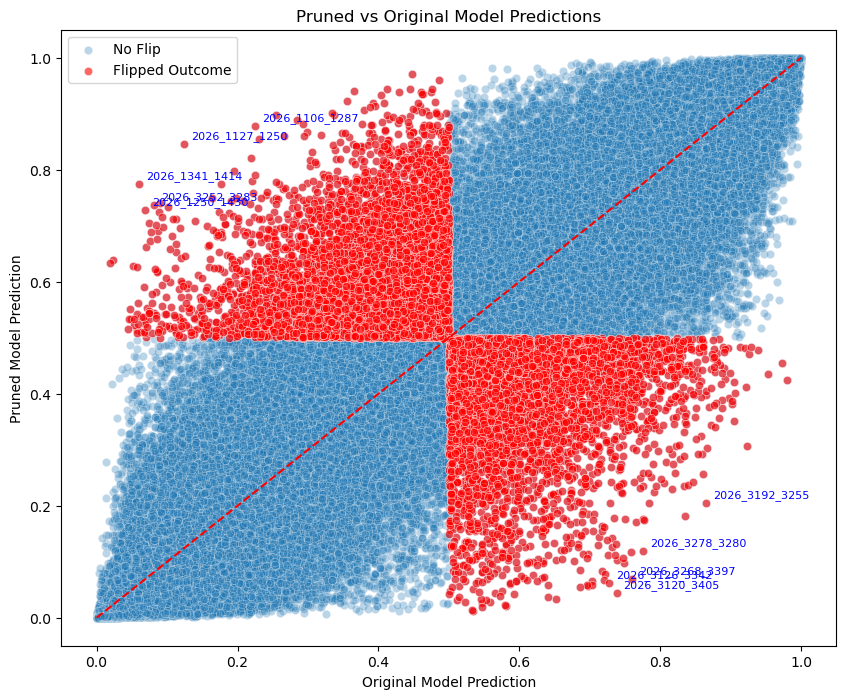

In [100]:
# Identify largest flips
top_flips = model_comp.loc[model_comp['flip']].copy()
top_flips['abs_diff'] = top_flips['pred_diff'].abs()
top_flips = top_flips.sort_values('abs_diff', ascending=False).head(10)

# Scatterplot
plt.figure(figsize=(10,8))
sns.scatterplot(
    x='pred_pruned',
    y='pred_XGBoost',
    data=model_comp,
    alpha=0.3,
    label='No Flip'
)
sns.scatterplot(
   x='pred_pruned',
    y='pred_XGBoost',
    data=model_comp[model_comp['flip']],
    color='red',
    alpha=0.6,
    label='Flipped Outcome'
)
plt.plot([0,1], [0,1], 'r--')
plt.xlabel('Original Model Prediction')
plt.ylabel('Pruned Model Prediction')
plt.title('Pruned vs Original Model Predictions')

# Annotate largest flips
for idx, row in top_flips.iterrows():
    plt.text(
        row['pred_pruned']+0.01,
        row['pred_XGBoost']+0.01,
        row['ID'],
        fontsize=8,
        color='blue'
    )

In [101]:
display(top_flips)

,ID,pred_XGBoost,win_XGBoost,pred_pruned,win_pruned,pred_diff,flip,abs_diff
8236,2026_1127_1250,0.846115,Win,0.123682,Loss,0.722433,True,0.722433
57320,2026_1341_1414,0.774563,Win,0.060280,Loss,0.714283,True,0.714283
72720,2026_3120_3405,0.044515,Loss,0.737881,Win,-0.693366,True,0.693366
111346,2026_3268_3397,0.069867,Loss,0.760276,Win,-0.690409,True,0.690409
74369,2026_3126_3342,0.062459,Loss,0.727346,Win,-0.664887,True,0.664887
93412,2026_3192_3255,0.204047,Loss,0.865239,Win,-0.661192,True,0.661192
41628,2026_1250_1430,0.727207,Win,0.068107,Loss,0.659100,True,0.659100
113219,2026_3278_3280,0.118396,Loss,0.775790,Win,-0.657393,True,0.657393
107853,2026_3252_3283,0.736529,Win,0.080993,Loss,0.655536,True,0.655536
1982,2026_1106_1287,0.877892,Win,0.224386,Loss,0.653506,True,0.653506


#### Investigating Differences in Importance

In [102]:
### XGBoost importance
XGBoost_importance = importance_table.copy()
XGBoost_importance = XGBoost_importance.rename(columns={'Importance':'Importance_XGBoost'})
display(XGBoost_importance)

,Feature,Importance_XGBoost
0,pt_diff,0.549487
5,conf_diff,0.154950
6,winpercintourney_diff,0.079953
1,winsbefore_diff,0.066939
2,winsafter_diff,0.056791
3,clutch_diff,0.050388
4,seed_diff,0.041491


In [103]:
pruned_importance = pd.read_csv("pruned_importance.csv", sep=',', index_col=None).rename(columns={'Feature_pruned':'Feature'})
display(pruned_importance)

,Feature,Importance_pruned
0,winpercintourney_diff,0.728791
1,pt_diff,0.699831
2,winsbefore_diff,0.309867
3,winsafter_diff,0.197483
4,clutch_diff,0.148566
5,top_a,0.142749
6,top_b,0.137561
7,mid_a,0.108943
8,conf_diff,0.103512
9,mid_b,0.060397


In [104]:
importance_comparison = XGBoost_importance.merge(pruned_importance, how='outer', on='Feature').fillna(0)
display(importance_comparison)

,Feature,Importance_XGBoost,Importance_pruned
0,blk_diff,0.000000,0.034990
1,clutch_diff,0.050388,0.148566
2,conf_diff,0.154950,0.103512
3,efg_diff,0.000000,0.051084
4,mid_a,0.000000,0.108943
5,mid_b,0.000000,0.060397
6,pt_diff,0.549487,0.699831
7,seed_diff,0.041491,0.000000
8,to_diff,0.000000,0.045836
9,top_a,0.000000,0.142749


In [105]:
# Calculate Difference
importance_comparison['Diff'] = importance_comparison['Importance_XGBoost'] - importance_comparison['Importance_pruned']

display(importance_comparison.sort_values('Importance_XGBoost', ascending=False))

,Feature,Importance_XGBoost,Importance_pruned,Diff
6,pt_diff,0.549487,0.699831,-0.150344
2,conf_diff,0.154950,0.103512,0.051438
11,winpercintourney_diff,0.079953,0.728791,-0.648837
13,winsbefore_diff,0.066939,0.309867,-0.242928
12,winsafter_diff,0.056791,0.197483,-0.140692
1,clutch_diff,0.050388,0.148566,-0.098177
7,seed_diff,0.041491,0.000000,0.041491
0,blk_diff,0.000000,0.034990,-0.034990
3,efg_diff,0.000000,0.051084,-0.051084
4,mid_a,0.000000,0.108943,-0.108943


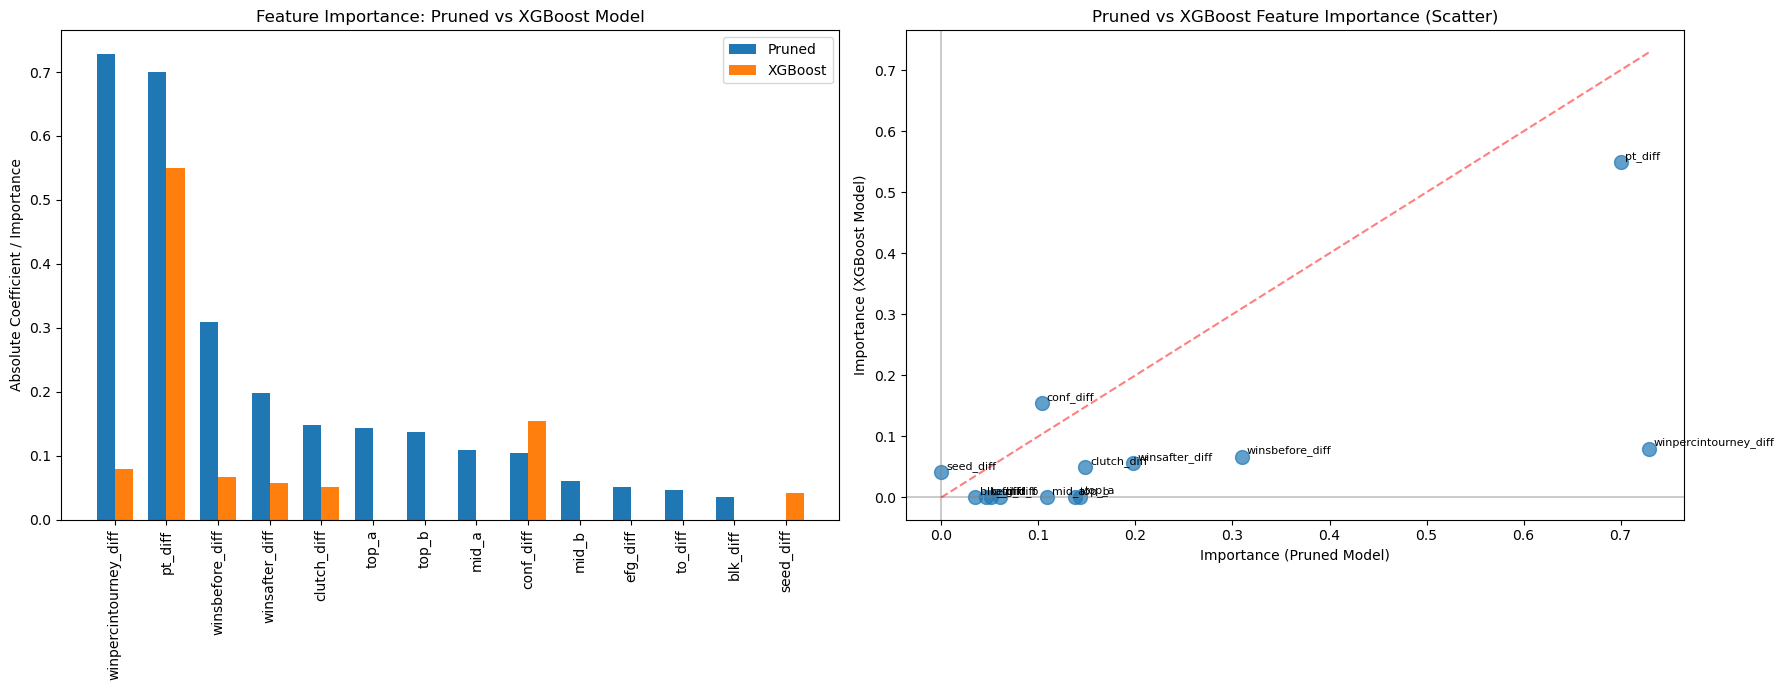

In [106]:
### Plot differences

# Sort by original importance
importance_comparison_sorted = importance_comparison.sort_values(
    by='Importance_pruned', ascending=False
)

### Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

### Bar Chart
ax = axes[0]

bar_width = 0.35
x = np.arange(len(importance_comparison_sorted))

ax.bar(x - bar_width/2, importance_comparison_sorted['Importance_pruned'],
       width=bar_width, label='Pruned')
ax.bar(x + bar_width/2, importance_comparison_sorted['Importance_XGBoost'],
       width=bar_width, label='XGBoost')

ax.set_xticks(x)
ax.set_xticklabels(importance_comparison_sorted['Feature'], rotation=90)
ax.set_ylabel('Absolute Coefficient / Importance')
ax.set_title('Feature Importance: Pruned vs XGBoost Model')
ax.legend()

### Scatterplot
ax = axes[1]

ax.scatter(
    importance_comparison['Importance_pruned'],
    importance_comparison['Importance_XGBoost'],
    s=100, alpha=0.7
)

# Annotate the points
for _, row in importance_comparison.iterrows():
    ax.text(
        row['Importance_pruned'] + 0.005,
        row['Importance_XGBoost'] + 0.005,
        row['Feature'],
        fontsize=8
    )

# Axes lines and diagonal
ax.axhline(0, color='gray', alpha=0.4)
ax.axvline(0, color='gray', alpha=0.4)

max_orig = importance_comparison['Importance_pruned'].max()
max_pruned = importance_comparison['Importance_XGBoost'].max()
line_max = max(max_orig, max_pruned)

ax.plot([0, line_max], [0, line_max], 'r--', alpha = 0.5)

ax.set_xlabel('Importance (Pruned Model)')
ax.set_ylabel('Importance (XGBoost Model)')
ax.set_title('Pruned vs XGBoost Feature Importance (Scatter)')

plt.tight_layout()
plt.show()

### Explaining the Flips

#### The Pruned Logistic regression model was dominated by pt_diff and winpercintourney, whereas in XGBoost the gains are smaller in magnitude relative to other features
#### Conf_diff and Seed_diff see higher importance in XGBoost, suggesting that tree-based splits pick up nonlinear thresholds that logistic regression cannot capture
#### Several features are heavily weighted in the pruned logistic model, but near-zero in XGBoost
> #### This may suggest multicollinearity or linear combination effects
> #### XGBoost handles interactions internally without explicily weighting all correlated features

### Conclusions
> #### pt_diff remains the strongest overall predictor across models
> #### Logistic regression emphasizes cumulative linear contributions of correlated variables
> #### XGBoost selectively picks the splits that improve logloss/gain, ignoring some correlated features that don't add unique predictive value